<a href="https://colab.research.google.com/github/bajon1/Deep-learning-lab/blob/main/Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install torch torchvision matplotlib numpy

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.10.0+cu128
GPU available: True
Device: Tesla T4


# Lab 2: PyTorch & Gradient Descent

## Task 1: Implement a function that computes mean & std of a tensor and moves it to GPU if available.

- Create tensors (zeros, ones, randn)
- Math operations (+, *, @)
- Reshape (reshape, view)
- Difference between torch.tensor vs torch.as_tensor
- CPU ↔ GPU transfer

In [18]:
torch.manual_seed(42)

In [19]:
zeros = torch.zeros(2, 3)
ones = torch.ones(2, 3)
randn = torch.randn(2, 3)

print(f"zeros: {zeros}")
print(f"ones: {ones}")
print(f"randn: {randn}")

zeros: tensor([[0., 0., 0.],
        [0., 0., 0.]])
ones: tensor([[1., 1., 1.],
        [1., 1., 1.]])
randn: tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])


In [20]:
zeros += 1
print(f"zeros: {zeros}")

zeros = torch.zeros(2, 3)
opz = 2*ones + zeros
print(f"two times ones plus zeros: {opz}")

multi = ones @ randn.T
print(f"matrix multiplication of ones and transposed randn: {multi}")

zeros: tensor([[1., 1., 1.],
        [1., 1., 1.]])
two times ones plus zeros: tensor([[2., 2., 2.],
        [2., 2., 2.]])
matrix multiplication of ones and transposed randn: tensor([[ 0.7000, -1.0789],
        [ 0.7000, -1.0789]])


In [21]:
t1 = randn.reshape(1, 6)
print(f"reshape of continous tensor: {t1}")

t2 = randn.T.reshape(1, 6)
print(f"reshape of of transposed tensor: {t2}")

t3 = randn.view(1, 6)
print(f"view of continous tensor: {t3}")

# t4 = randn.T.view(1, 6) # error, viewed tensors must be continous
print(f"view of of transposed tensor: Error")

reshape of continous tensor: tensor([[ 0.3367,  0.1288,  0.2345,  0.2303, -1.1229, -0.1863]])
reshape of of transposed tensor: tensor([[ 0.3367,  0.2303,  0.1288, -1.1229,  0.2345, -0.1863]])
view of continous tensor: tensor([[ 0.3367,  0.1288,  0.2345,  0.2303, -1.1229, -0.1863]])
view of of transposed tensor: Error


In [22]:
randn += 1

print(f"reshape/view check if it copy or view, if < 1 it's copy, if 1 > it's view : \nreshape of continous tensor: {t1}, \nreshape of of transposed tensor: {t2}, \nview of continous tensor: {t3}")

randn -= 1

reshape/view check if it copy or view, if < 1 it's copy, if 1 > it's view : 
reshape of continous tensor: tensor([[ 1.3367,  1.1288,  1.2345,  1.2303, -0.1229,  0.8137]]), 
reshape of of transposed tensor: tensor([[ 0.3367,  0.2303,  0.1288, -1.1229,  0.2345, -0.1863]]), 
view of continous tensor: tensor([[ 1.3367,  1.1288,  1.2345,  1.2303, -0.1229,  0.8137]])


In [23]:
arr = np.array([[1, 2], [3, 4], [5, 6]])

print(f"Numpy array: {arr}")

tensor = torch.tensor(arr)
nottensor = torch.as_tensor(arr)

print(f"Numpy to tensor copy: {tensor}")
print(f"Numpy to tensor view: {nottensor}")

arr += 1

print(f"Tensor after addition: {tensor}")
print(f"As_tensor after addition: {nottensor}")

Numpy array: [[1 2]
 [3 4]
 [5 6]]
Numpy to tensor copy: tensor([[1, 2],
        [3, 4],
        [5, 6]])
Numpy to tensor view: tensor([[1, 2],
        [3, 4],
        [5, 6]])
Tensor after addition: tensor([[1, 2],
        [3, 4],
        [5, 6]])
As_tensor after addition: tensor([[2, 3],
        [4, 5],
        [6, 7]])


In [24]:
print(f"Tensor device before change: {t1.device}")

device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"
t1 = t1.to(device)

print(f"Tensor device after change: {t1.device}")

Tensor device before change: cpu
Tensor device after change: cuda:0


## Task 2 – Manual Gradient Descent:

- synthetic data y = 2x + 1 + noise,
- predictions ŷ = b + w·x, MSE loss,
- hand-computed gradients,
- parameter update loop. Train for 1000 epochs and plot loss curve.

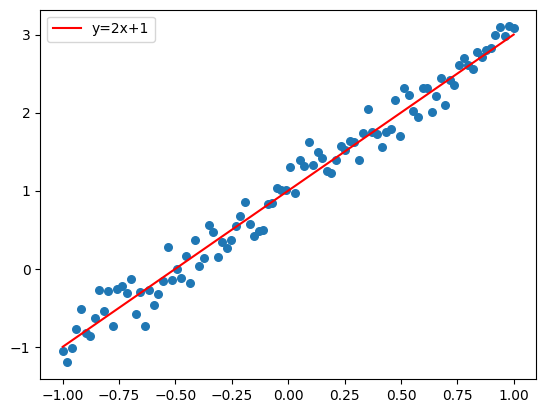

In [25]:
N = 100

x = torch.linspace(-1, 1, N)
noise = torch.randn(N) * 0.2

y = 2*x + 1 + noise

plt.scatter(x, y, s=30)
plt.plot(x, 2*x+1, color='r', label="y=2x+1")
plt.legend()
plt.show()

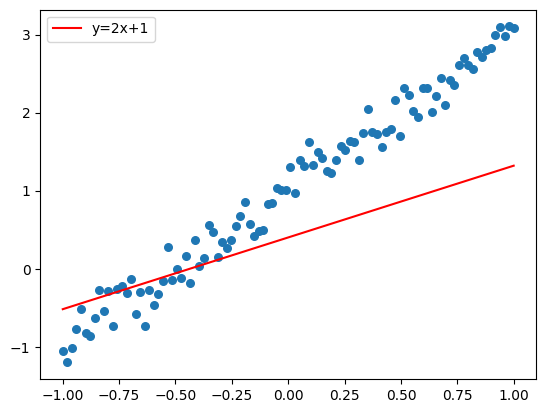

MSE: 0.8115472197532654
True MSE: 0.03419741988182068


In [26]:
w = torch.rand(1) # start with random values
b = torch.rand(1)

y_hat = w*x + b

plt.scatter(x, y, s=30)
plt.plot(x, y_hat, color='r', label="y=2x+1")
plt.legend()
plt.show()

MSE = torch.mean((y_hat - y)**2)
true_MSE = torch.mean((2*x+1 - y)**2)

print(f"MSE: {MSE}")
print(f"True MSE: {true_MSE}")

In [27]:
loss = torch.mean((w*x + b - y)**2)
dw = torch.mean(2*(w*x + b - y)*x)
db = torch.mean(2*(w*x + b - y)*1)

In [28]:
epochs = 13000
lr = 3e-4

for epoch in range(0, epochs):
  loss = torch.mean((w*x + b - y)**2)
  dw = torch.mean(2*(w*x + b - y)*x)
  db = torch.mean(2*(w*x + b - y)*1)
  w -= lr + dw
  b -= lr * db
  print(f"Loss: {loss}")

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
Loss: 0.03405021131038666
Loss: 0.03405017778277397
Loss: 0.03405015170574188
Loss: 0.034050118178129196
Loss: 0.03405009210109711
Loss: 0.03405005857348442
Loss: 0.03405003249645233
Loss: 0.034049998968839645
Loss: 0.034049972891807556
Loss: 0.03404993936419487
Loss: 0.03404991328716278
Loss: 0.034049879759550095
Loss: 0.034049853682518005
Loss: 0.03404982388019562
Loss: 0.03404979407787323
Loss: 0.034049760550260544
Loss: 0.034049734473228455
Loss: 0.03404970094561577
Loss: 0.03404967486858368
Loss: 0.03404964506626129
Loss: 0.0340496189892292
Loss: 0.03404958173632622
Loss: 0.03404955565929413
Loss: 0.03404952585697174
Loss: 0.03404949977993965
Loss: 0.034049466252326965
Loss: 0.03404943645000458
Loss: 0.03404940664768219
Loss: 0.0340493805706501
Loss: 0.034049347043037415
Loss: 0.03404931724071503
Loss: 0.03404929116368294
Loss: 0.03404926136136055
Loss: 0.034049227833747864
Loss: 0.034049201756715775
Loss: 0.03404917

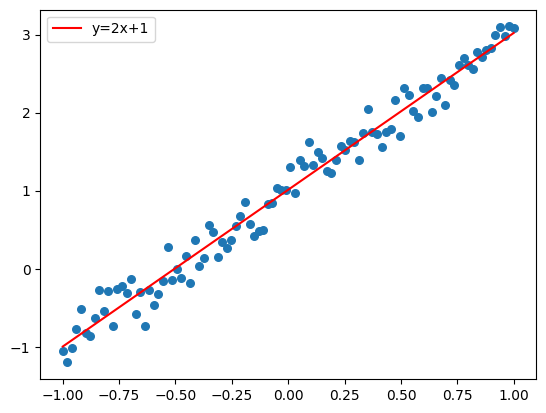

MSE: 0.03402503952383995
True MSE: 0.03419741988182068


In [29]:
y_hat = w*x + b

plt.scatter(x, y, s=30)
plt.plot(x, y_hat, color='r', label="y=2x+1")
plt.legend()
plt.show()

MSE = torch.mean((y_hat - y)**2)
true_MSE = torch.mean((2*x+1 - y)**2)

print(f"MSE: {MSE}")
print(f"True MSE: {true_MSE}")

# Task 3 – Autograd:

- rewrite Task 2 using requires_grad=True and loss.backward()
- update params inside torch.no_grad().
- compare execution time and final parameter values vs manual implementation.

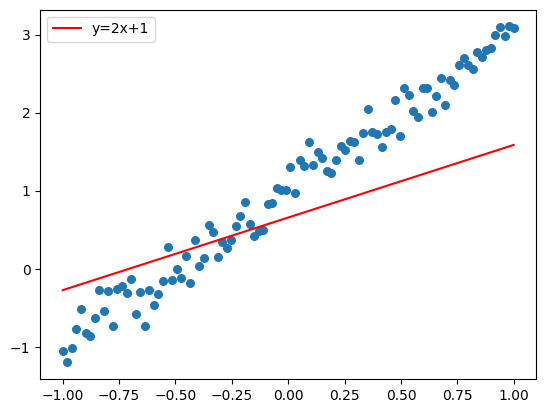

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
Loss: 0.03402518853545189
Loss: 0.03402518481016159
Loss: 0.03402518853545189
Loss: 0.03402518481016159
Loss: 0.03402518853545189
Loss: 0.03402518481016159
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518481016159
Loss: 0.03402518481016159
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518481016159
Loss: 0.03402518108487129
Loss: 0.03402518481016159
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.034025177359580994
Loss: 0.03402518108487129
Loss: 0.034025177359580994
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.034025177359580994
Loss: 0.03402518108487129
Loss: 0.03402518108487129
Loss: 0.03402518481016

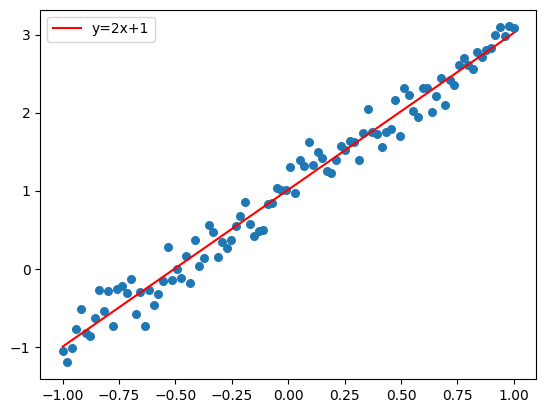

MSE: 0.034025028347969055
True MSE: 0.03419741988182068


In [30]:
w = torch.rand(1, requires_grad=True) # start with random values
b = torch.rand(1, requires_grad=True)

y_hat = w*x + b

plt.scatter(x, y, s=30)
plt.plot(x, y_hat.detach().numpy(), color='r', label="y=2x+1")
plt.legend()
plt.show()

MSE = torch.mean((y_hat - y)**2)
true_MSE = torch.mean((2*x+1 - y)**2)

print(f"MSE: {MSE}")
print(f"True MSE: {true_MSE}")

epochs = 40000
lr = 3e-4

for epoch in range(0, epochs):
  loss = torch.mean((w*x + b - y)**2)
  print(f"Loss: {loss}")
  loss.backward()
  with torch.no_grad():
    w -= lr * w.grad
    b -= lr * b.grad
  w.grad.zero_()
  b.grad.zero_()

y_hat = w*x + b
MSE = torch.mean((y_hat - y)**2)

plt.scatter(x, y, s=30)
plt.plot(x, y_hat.detach().numpy(), color='r', label="y=2x+1")
plt.legend()
plt.show()

print(f"MSE: {MSE}")
print(f"True MSE: {true_MSE}")

Autograd has lower efficiency because of gradient graph and internal implementation of autograd. When done by hand only calculations must be run which is faster and more epoch efficient.

Task 4 – nn.Module & nn.Linear:
- build LinearRegression(nn.Module) with one nn.Linear layer
- implement forward()
- inspect parameters via state_dict(),
- test with a forward pass.

In [31]:
N = 100

x = torch.linspace(-1, 1, N)
noise = torch.randn(N) * 0.2

y = 2*x + 1 + noise

x = x.view(N,1)
y = y.view(N,1)

print(x.shape, y.shape)

torch.Size([100, 1]) torch.Size([100, 1])


In [35]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(1, 1)
  def forward(self, x):
    logits = self.linear(x)
    return logits

In [36]:
model = LinearRegression().to(device)
print(model.state_dict())

OrderedDict({'linear.weight': tensor([[-0.1764]], device='cuda:0'), 'linear.bias': tensor([-0.4847], device='cuda:0')})
